In [1]:
import os
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, wasserstein_distance, chisquare, norm
import matplotlib.pyplot as plt
from collections import deque
import numpy as np
import requests as req
from numpy.random import PCG64, Generator
from ast import literal_eval

In [2]:
PLOT_MAP = [
    #Gen ROW COLUMN
    ("pcg64".upper(), 0, 0),
    ("mt19937".upper(),0, 1),
    ("philox".upper(),1, 0),
    ("sfc64".upper(), 1, 1),
    ("TRNG".upper(), 2, 0)
]
generators = ["pcg64", "mt19937", "philox", "sfc64"]

In [3]:
PROJECT_ROOT_DIR = "./."
BASE_IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", "summary")
os.makedirs(BASE_IMAGES_PATH, exist_ok = True)

def save_figure(fig_id, image_path, tight_layout = True, fig_extension = "png", resolution = 300):
    path = os.path.join(image_path, fig_id + "." + fig_extension)
    print(f"Saving figure {fig_id}")
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format = fig_extension, dpi = resolution)

In [4]:
class Qrng:
    def __init__(self, domain) -> None:
        self.__domain = domain
        self.__api_int = "https://{}/api/2.0/int".format(self.__domain)
        self.__api_bytes ="https://{}/api/2.0/streambytes".format(self.__domain)

    def qrand_int(self, low, hi, samples) -> list[int]:
        session = req.Session()
        payload = {"min": low, "max": hi, "quantity": samples}
        response = session.get(self.__api_int, params = payload)
        res = literal_eval(response.text)
        return res

    def qrand_bytes(self, size) -> bytes:
        session = req.Session()
        payload = {"size": size}
        response = session.get(self.__api_bytes, params = payload)
        
        return response.content

def qrandbytes(size=1024) -> bytes:
    qrng = Qrng("random.cs.upt.ro")
    values = qrng.qrand_bytes(size)
    return values
    
def qrandint(l, h, n, pool_size = 100000) -> np.array:
    if not hasattr(qrandint, "ivalues"):
       qrandint.ivalues = {}

    key = str(l) + str(h)
    if key in qrandint.ivalues:
        # found the key
        values = qrandint.ivalues[key]
        if len(values) == 0 or len(values) < n:
            qrng = Qrng("random.cs.upt.ro")
            values = qrng.qrand_int(l, h, (n + pool_size))
            qrandint.ivalues[key] += values
        else:
            pass
    else:
        qrng = Qrng("random.cs.upt.ro")
        qrandint.ivalues[key] = qrng.qrand_int(l, h, (n + pool_size))

    outvals = qrandint.ivalues[key][:n]
    del qrandint.ivalues[key][:n]
    return np.array(outvals, dtype = np.uint32)

In [5]:
def randint(l, h, n, generator="pcg64", seed=None, dtype = np.uint32):
    generators = {
        "pcg64": np.random.PCG64,
        "mt19937": np.random.MT19937,
        "philox": np.random.Philox,
        "sfc64": np.random.SFC64,
    }
    if generator not in generators:
        raise ValueError(f"Unknown generator: {generator}. Choose from {list(generators.keys())}")
    rng = np.random.default_rng(generators[generator](seed))
    return rng.integers(l, h, size=n, dtype=dtype)

In [6]:
RANGE_MIN = 0
RANGE_MAX = 1000
ARRAY_SIZE = 10000

In [7]:
data = [
    *[(gen_i.upper(), randint(RANGE_MIN, RANGE_MAX + 1, ARRAY_SIZE, generator=gen_i)) for gen_i in generators],
    ("TRNG",qrandint(RANGE_MIN, RANGE_MAX + 1, ARRAY_SIZE, pool_size = 100000))
    
]

In [8]:
data

[('PCG64',
  array([206, 516,  88, ..., 571, 148, 547], shape=(10000,), dtype=uint32)),
 ('MT19937',
  array([503, 777,  68, ..., 520, 916,  14], shape=(10000,), dtype=uint32)),
 ('PHILOX',
  array([298, 175, 164, ..., 276, 158, 518], shape=(10000,), dtype=uint32)),
 ('SFC64',
  array([535, 468, 232, ..., 353, 507, 671], shape=(10000,), dtype=uint32)),
 ('TRNG',
  array([710, 509, 584, ..., 970, 224, 613], shape=(10000,), dtype=uint32))]

# Analyzing data

Saving figure uniformity


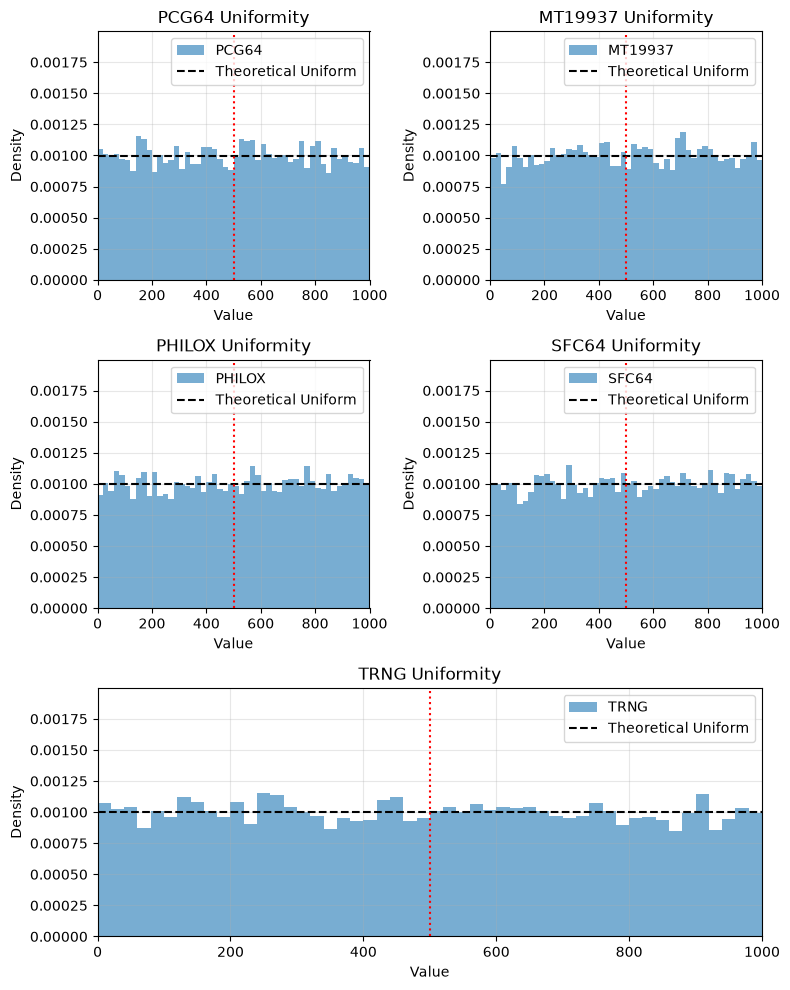

In [9]:
bins = 50
k = RANGE_MAX - RANGE_MIN + 1

####
fig = plt.figure(figsize=(8, 10))
gs = fig.add_gridspec(3, 2)
axes = []

mean_theoretical = (RANGE_MIN + RANGE_MAX) / 2
for (generator, row, column) in PLOT_MAP:
    if generator == "TRNG":
        ax = fig.add_subplot(gs[row, :])
    else:
        ax = fig.add_subplot(gs[row, column])
    value = next(item[1] for item in data if item[0] == generator)
    ax.hist(value, bins=bins, alpha=0.6, density=True, label=generator)
    ax.hlines(
        y=1/k,
        xmin=RANGE_MIN,
        xmax=RANGE_MAX,
        colors="black",
        linestyles="dashed",
        label="Theoretical Uniform"
    )
    ax.set_title(f"{generator} Uniformity")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()
    axes.append(ax)


for i, ax in enumerate(axes):
    ax.set_xlim(RANGE_MIN, RANGE_MAX)
    ax.set_ylim(0, 2/k)
    ax.grid(alpha=0.3)
    ax.axvline(mean_theoretical, color="red", linestyle=":", label="Mean")


plt.tight_layout()
save_figure("uniformity", BASE_IMAGES_PATH)
plt.show()








Saving figure spread_comparison_boxplot


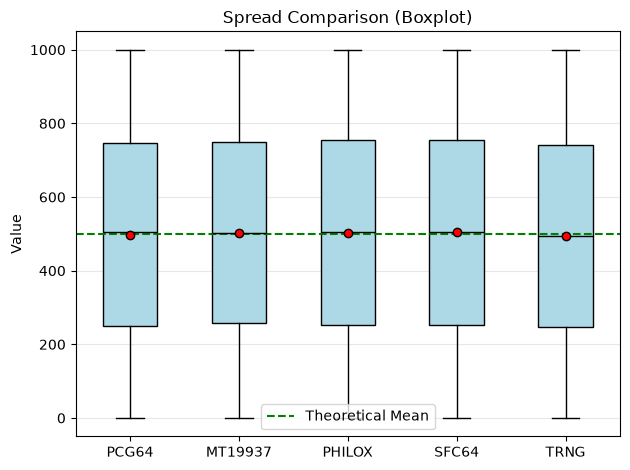

In [10]:
plt.figure()
mean_theoretical = (RANGE_MIN + RANGE_MAX) / 2

labels, arrays = map(list, zip(*data))

plt.boxplot(
    arrays,
    tick_labels=labels,
    showmeans=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
    medianprops=dict(color="black"),
    meanprops=dict(marker="o", markerfacecolor="red", markeredgecolor="black")
)

plt.axhline(
    mean_theoretical,
    color="green",
    linestyle="--",
    label="Theoretical Mean"
)

plt.title("Spread Comparison (Boxplot)")
plt.ylabel("Value")
plt.grid(axis="y", alpha=0.3)
plt.legend()
save_figure("spread_comparison_boxplot", BASE_IMAGES_PATH)
plt.show()

Saving figure deviation_from_uniform_distribution


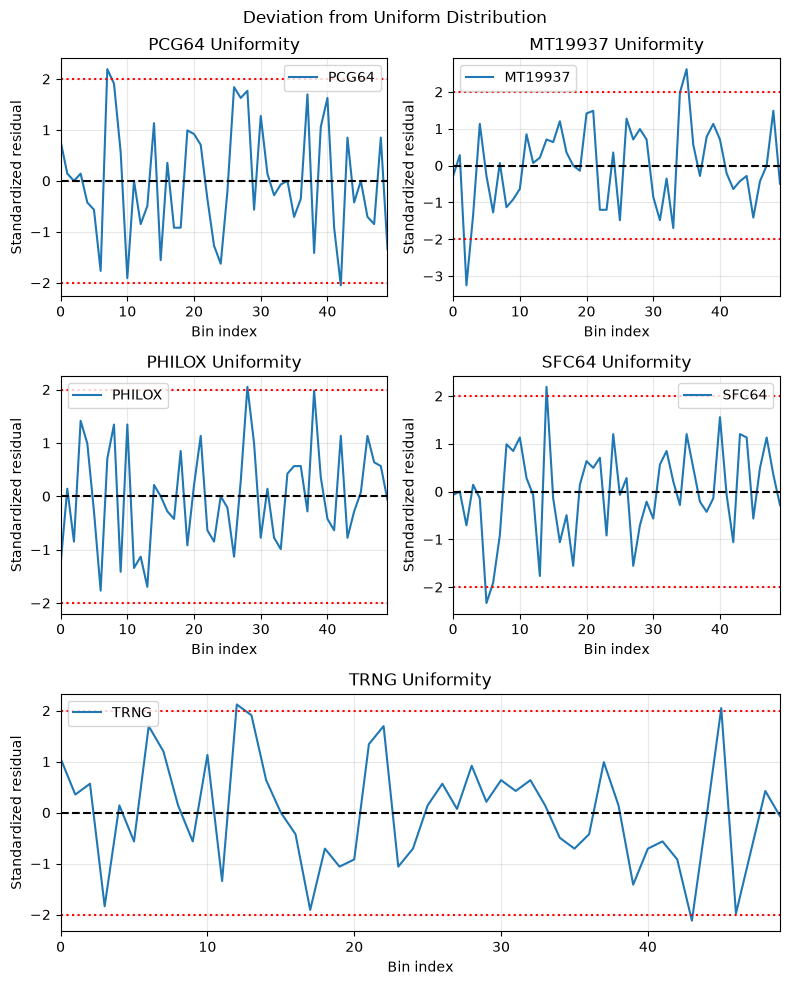

In [11]:
bins = 50
expected_prob = 1 / bins   # IMPORTANT: matches histogram bins!

fig = plt.figure(figsize=(8, 10))
gs = fig.add_gridspec(3, 2)
axes = []

mean_theoretical = (RANGE_MIN + RANGE_MAX) / 2
for generator, row, column in PLOT_MAP:

    value = next(item[1] for item in data if item[0] == generator)

    value_hist, _ = np.histogram(
        value,
        bins=bins,
        range=(RANGE_MIN, RANGE_MAX)
    )

    expected_count = len(value) / bins

    residual = (
        value_hist - expected_count
    ) / np.sqrt(expected_count)

    x = np.arange(bins)

    if generator == "TRNG":
        ax = fig.add_subplot(gs[row, :])
    else:
        ax = fig.add_subplot(gs[row, column])

    ax.plot(x, residual, label=generator)

    ax.axhline(0, linestyle="--", color="black")
    ax.axhline(2, linestyle=":", color="red")
    ax.axhline(-2, linestyle=":", color="red")

    ax.set_xlim(0, bins - 1)
    ax.set_ylabel("Standardized residual")
    ax.set_xlabel("Bin index")
    ax.set_title(f"{generator} Uniformity")
    ax.grid(alpha=0.3)
    ax.legend()

    axes.append(ax)

fig.suptitle("Deviation from Uniform Distribution")

fig.tight_layout()

save_figure(
    "deviation_from_uniform_distribution",
    BASE_IMAGES_PATH
)

plt.show()


In [12]:
from statsmodels.distributions.empirical_distribution import ECDF

Saving figure cdf_deviation


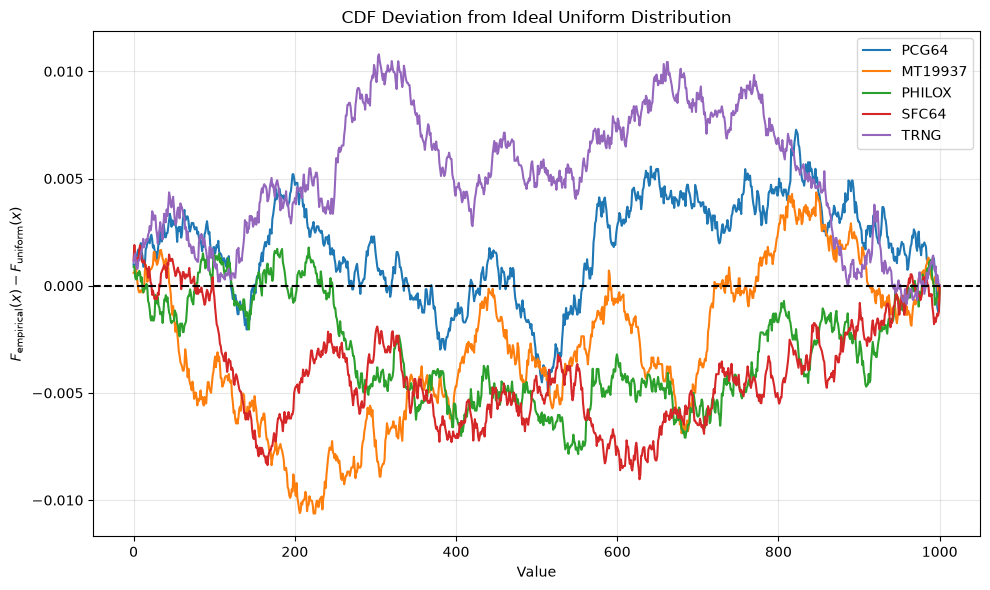

In [13]:
plt.figure(figsize=(10, 6))

x = np.linspace(RANGE_MIN, RANGE_MAX, 1000)

ideal_cdf = (x - RANGE_MIN) / (RANGE_MAX - RANGE_MIN)

for generator, array in data:
    value_ecdf = ECDF(array)

    deviation = value_ecdf(x) - ideal_cdf

    plt.plot(
        x,
        deviation,
        label=generator
    )

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Value")
plt.ylabel(r"$F_{\mathrm{empirical}}(x) - F_{\mathrm{uniform}}(x)$")
plt.title("CDF Deviation from Ideal Uniform Distribution")

plt.legend()
plt.grid(alpha=0.3)

save_figure("cdf_deviation", BASE_IMAGES_PATH)
plt.show()

# Statistical moments

In [14]:
theoretical_mean = (RANGE_MAX - 1) / 2
print(f"Theoretical Mean:{theoretical_mean}")
for generator, array in data:
    array_mean = np.mean(array)
    array_error = array_mean - theoretical_mean

    array_relative_error = abs(array_error)/theoretical_mean
    print(f"{generator}:\n\tMean:{array_mean}\n\tError:{array_error}\n\tRelative Error:{array_relative_error}\n================")

Theoretical Mean:499.5
PCG64:
	Mean:498.1725
	Error:-1.3274999999999864
	Relative Error:0.0026576576576576305
MT19937:
	Mean:502.9559
	Error:3.4558999999999855
	Relative Error:0.0069187187187186895
PHILOX:
	Mean:503.0596
	Error:3.559599999999989
	Relative Error:0.007126326326326304
SFC64:
	Mean:504.1121
	Error:4.612099999999998
	Relative Error:0.009233433433433429
TRNG:
	Mean:494.8448
	Error:-4.655199999999979
	Relative Error:0.009319719719719679


In [15]:
theoretical_std = np.sqrt((RANGE_MAX ** 2 - 1) / 12)
print(f"Theoretical STD:{theoretical_std}")

for generator, arr in data:
    arr_std = np.std(arr)
    arr_error = arr_std - theoretical_std
    arr_relative_error = abs(arr_error)/theoretical_std
    print(f"{generator.upper()}:\n\tStd:{arr_std}\n\tError:{arr_error}\n\tRelative Error:{arr_relative_error}\n================")
                          


Theoretical STD:288.6749902572095
PCG64:
	Std:287.68183665944224
	Error:-0.9931535977672752
	Relative Error:0.003440386702299271
MT19937:
	Std:286.19236390090845
	Error:-2.4826263563010684
	Relative Error:0.008600074270684299
PHILOX:
	Std:289.0757223425032
	Error:0.40073208529366866
	Relative Error:0.0013881773579921704
SFC64:
	Std:288.5086711584073
	Error:-0.1663190988022052
	Relative Error:0.0005761465468623202
TRNG:
	Std:288.25635554651694
	Error:-0.4186347106925723
	Relative Error:0.0014501939025599988


In [16]:
theoretical_skew = 0
print(f"Theoretical Skew: {theoretical_skew}\n")
for generator, arr in data:
    arr_skew = skew(arr)
    print(f"{generator} Skew {arr_skew}\n================")

Theoretical Skew: 0

PCG64 Skew -0.005645993849897482
MT19937 Skew -0.010495742772708976
PHILOX Skew -0.01705659282531594
SFC64 Skew -0.0179403084474321
TRNG Skew 0.02037715026915989


In [17]:
theoretical_kurt = -1.2

theoretical_skew = 0
print(f"Theoretical kurtosis: {theoretical_skew}\n")
for generator, arr in data:
    arr_kurt = kurtosis(arr, fisher=True)
    print(f"{generator} Kurtosis {arr_kurt}\n================")



Theoretical kurtosis: 0

PCG64 Kurtosis -1.1903605459414852
MT19937 Kurtosis -1.1824931883563887
PHILOX Kurtosis -1.2047203493417409
SFC64 Kurtosis -1.1996977259753323
TRNG Kurtosis -1.1921378898333845


=== Pearson Chi-Square Test ===

PCG64:
	Chi2 statistic: 60.089999999999996
	p-value: 0.133149323323672
=== Pearson Chi-Square Test ===

MT19937:
	Chi2 statistic: 59.169999999999995
	p-value: 0.151481676362209
=== Pearson Chi-Square Test ===

PHILOX:
	Chi2 statistic: 43.25
	p-value: 0.7044225382210885
=== Pearson Chi-Square Test ===

SFC64:
	Chi2 statistic: 43.53999999999999
	p-value: 0.6933680985543873
=== Pearson Chi-Square Test ===

TRNG:
	Chi2 statistic: 55.45
	p-value: 0.2445711011963734
Saving figure chi_square


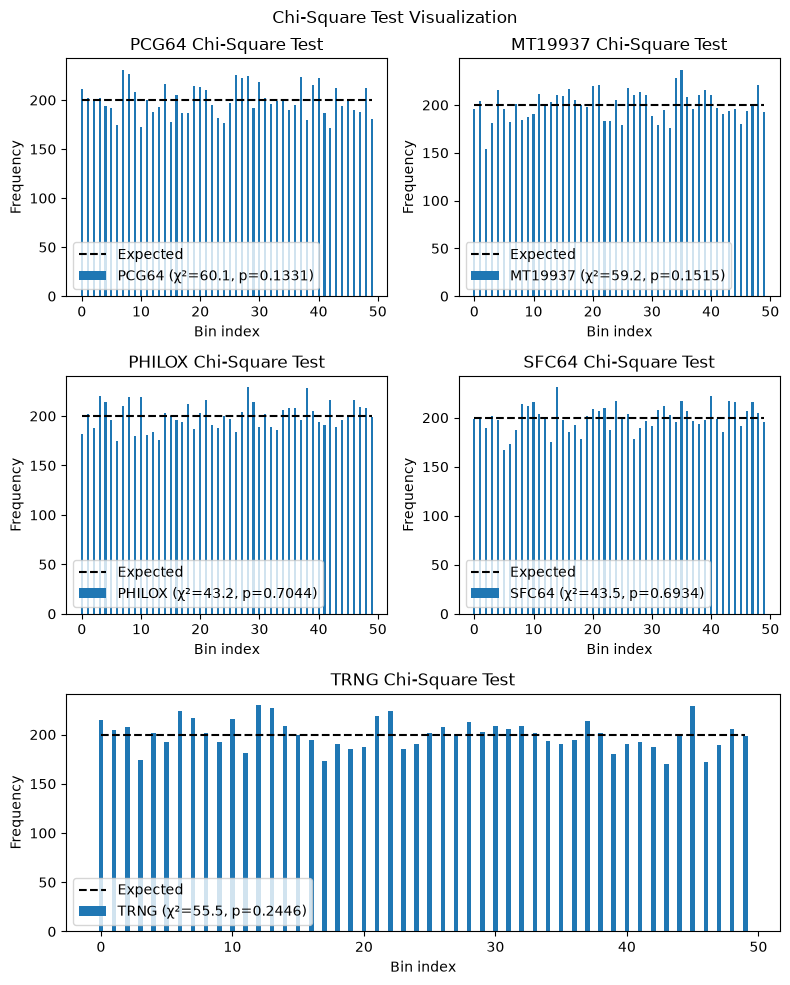

In [18]:
# --- Pearson Chi-Squared Test ---

bins = 50

fig = plt.figure(figsize=(8, 10))
gs = fig.add_gridspec(3, 2)
axes = []


x = np.arange(bins)
width = 0.35


for generator, row, column in PLOT_MAP:

    value = next(item[1] for item in data if item[0] == generator)

    value_hist, _ = np.histogram(value, bins=bins, range=(RANGE_MIN, RANGE_MAX))

    # Expected frequencies (uniform)
    expected = np.ones(bins) * (len(value) / bins)
    
    # Run test
    chi_g = chisquare(value_hist, expected)
    
    
    print("=== Pearson Chi-Square Test ===\n")
    
    print(f"{generator}:")
    print(f"\tChi2 statistic: {chi_g.statistic}")
    print(f"\tp-value: {chi_g.pvalue}\n=================")
    
    x = np.arange(bins)
    width = 0.35

    if generator == "TRNG":
        ax = fig.add_subplot(gs[row, :])
    else:
        ax = fig.add_subplot(gs[row, column])

    ax.bar(x, value_hist, width,
        label=f"{generator} (χ²={chi_g.statistic:.1f}, p={chi_g.pvalue:.4f})")
    ax.plot(x, expected, 'k--', label="Expected")

    ax.set_xlabel("Bin index")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{generator} Chi-Square Test")
    ax.legend()

    
    axes.append(ax)

fig.suptitle("Chi-Square Test Visualization")

fig.tight_layout()

save_figure(
    "chi_square",
    BASE_IMAGES_PATH
)

plt.show()

=== Wasserstein Distance ===

PCG64: 2.5386660766076448
MT19937: 3.851712881288137
PHILOX: 3.2267577357735986
SFC64: 4.195410351035127
TRNG: 5.166813881388114
Saving figure wasserstein


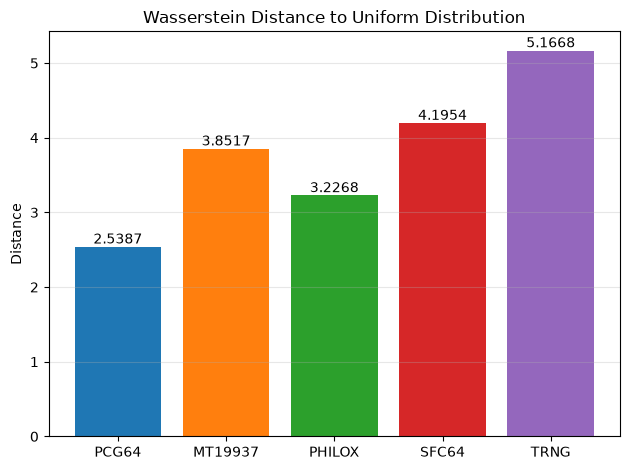

In [19]:

uniform_ref = np.linspace(RANGE_MIN, RANGE_MAX, ARRAY_SIZE)

labels, arrays = map(list, zip(*data))

w_distances = [
    wasserstein_distance(array, uniform_ref)
    for array in arrays
]


print("=== Wasserstein Distance ===\n")
for label, value in zip(labels,w_distances):
    print(f"{label}: {value}")


plt.figure()



plt.bar(labels, w_distances,color=plt.rcParams["axes.prop_cycle"].by_key()["color"][:len(labels)])

plt.title("Wasserstein Distance to Uniform Distribution")
plt.ylabel("Distance")

plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(w_distances):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom")

save_figure("wasserstein", BASE_IMAGES_PATH)
plt.show()

# MFDFA

In [20]:
from MFDFA import MFDFA
from scipy.stats import linregress

def extract_hq(lag, dfa):
    log_lag = np.log(lag)
    return np.array([linregress(log_lag, np.log(dfa[:, i])).slope for i in range(dfa.shape[1])])

Saving figure mfdfa


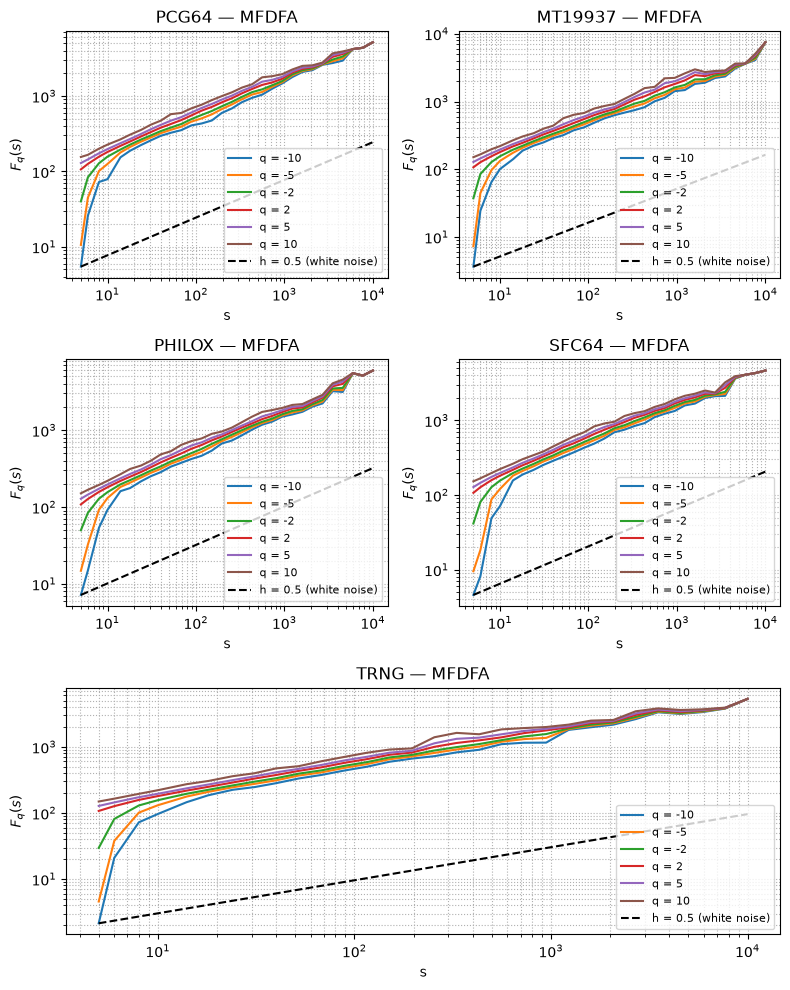

In [21]:
lag = np.logspace(0.7, 4, 30).astype(int)
q_list = np.linspace(-10, 10, 41)
q_list = q_list[q_list != 0.0]
order = 2
q_selected = [-10, -5, -2, 2, 5, 10]
####
fig = plt.figure(figsize=(8, 10))
gs = fig.add_gridspec(3, 2)
axes = []


for (generator, row, column) in PLOT_MAP:
    if generator == "TRNG":
        ax = fig.add_subplot(gs[row, :])
    else:
        ax = fig.add_subplot(gs[row, column])
        
    value = next(item[1] for item in data if item[0] == generator)
    
    lag_t, dfa_t = MFDFA(value, lag=lag, q=q_list, order=order)

    for q in q_selected:
        idx = np.where(q_list == q)[0][0]
        ax.loglog(lag_t, dfa_t[:, idx], label=f"q = {q}")
    idx_ref = np.where(q_list == q_selected[0])[0][0]
    ref_y = dfa_t[0, idx_ref] * (lag_t / lag_t[0]) ** 0.5
    ax.loglog(lag_t, ref_y, "k--", lw=1.5, label="h = 0.5 (white noise)")
    ax.set_xlabel("s")
    ax.set_ylabel(r"$F_q(s)$")
    ax.set_title(f"{generator} — MFDFA")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", ls=":")

    axes.append(ax)



plt.tight_layout()
save_figure("mfdfa", BASE_IMAGES_PATH)
plt.show()








Saving figure generalized_hurst_exponent
PCG64 h(q) range: [0.459, 0.646]
MT19937 h(q) range: [0.474, 0.648]
PHILOX h(q) range: [0.476, 0.666]
SFC64 h(q) range: [0.450, 0.672]
TRNG h(q) range: [0.461, 0.664]
White noise reference: h(q) = 0.5 for all q


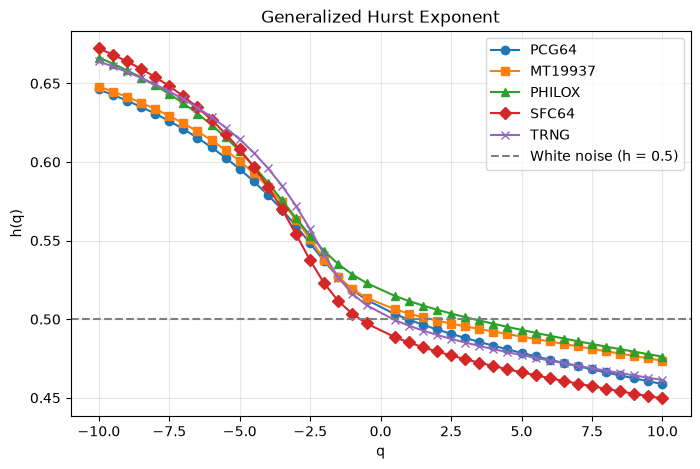

<Figure size 640x480 with 0 Axes>

In [22]:
lag = np.logspace(0.7, 4, 30).astype(int)
q_list = np.linspace(-10, 10, 41)
q_list = q_list[q_list != 0.0]
order = 2
q_selected = [-10, -5, -2, 2, 5, 10]
####

markers = ["o", "s", "^", "D", "x"]

labels, arrays = map(list, zip(*data))

mfdfas = [
    MFDFA(array, lag=lag, q=q_list, order=order) for array in arrays
]

hqs = [extract_hq(lag_t, dfa_t) for (lag_t,dfa_t) in mfdfas]

fig, ax = plt.subplots(figsize=(8, 5))


    
plt.figure()
for (label, value), marker in zip(zip(labels, hqs), markers):
    ax.plot(q_list, value, marker=marker,
        linestyle="-",label=f"{label}")

ax.axhline(0.5, color="gray", ls="--", lw=1.5, label="White noise (h = 0.5)")
ax.set_xlabel("q")
ax.set_ylabel("h(q)")
ax.set_title("Generalized Hurst Exponent")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_figure("generalized_hurst_exponent", BASE_IMAGES_PATH)


for (label, value) in zip(labels, hqs):
    print(f"{label} h(q) range: [{value.min():.3f}, {value.max():.3f}]")
print(f"White noise reference: h(q) = 0.5 for all q")



# Bit tests, entropy, NIST

In [23]:
BYTE_STREAM_SIZE = 102400

In [24]:
def bytes_to_bits(data: bytes) -> np.ndarray:
    return np.unpackbits(np.frombuffer(data, dtype = np.uint8))


def bit_frequency(data: bytes) -> dict:
    bits = bytes_to_bits(data)
    counts = np.bincount(bits)
    return {"0": int(counts[0]), "1": int(counts[1])}

In [25]:
data_bin = [
    *[(gen_i.upper(), randint(0, 256, BYTE_STREAM_SIZE, generator=gen_i, dtype=np.uint8).tobytes()) for gen_i in generators],
    ("TRNG",qrandbytes(BYTE_STREAM_SIZE))
    
]

In [26]:
for (label, value) in data_bin:
    bit_freq = bit_frequency(value)
    bit_stream_len = len(bytes_to_bits(value))
    print(f"{label} bit frequency: {bit_freq}")
    print(f"{label} fraction of 1s: {bit_freq['1']/bit_stream_len}\n=================")


PCG64 bit frequency: {'0': 408526, '1': 410674}
PCG64 fraction of 1s: 0.50131103515625
MT19937 bit frequency: {'0': 410165, '1': 409035}
MT19937 fraction of 1s: 0.499310302734375
PHILOX bit frequency: {'0': 409900, '1': 409300}
PHILOX fraction of 1s: 0.4996337890625
SFC64 bit frequency: {'0': 409730, '1': 409470}
SFC64 fraction of 1s: 0.49984130859375
TRNG bit frequency: {'0': 409791, '1': 409409}
TRNG fraction of 1s: 0.499766845703125


PCG64: chi2 = 5.6322, p-value = 0.0176
MT19937: chi2 = 1.5587, p-value = 0.2119
PHILOX: chi2 = 0.4395, p-value = 0.5074
SFC64: chi2 = 0.0825, p-value = 0.7739
TRNG: chi2 = 0.1781, p-value = 0.6730
Saving figure bit_chisquare


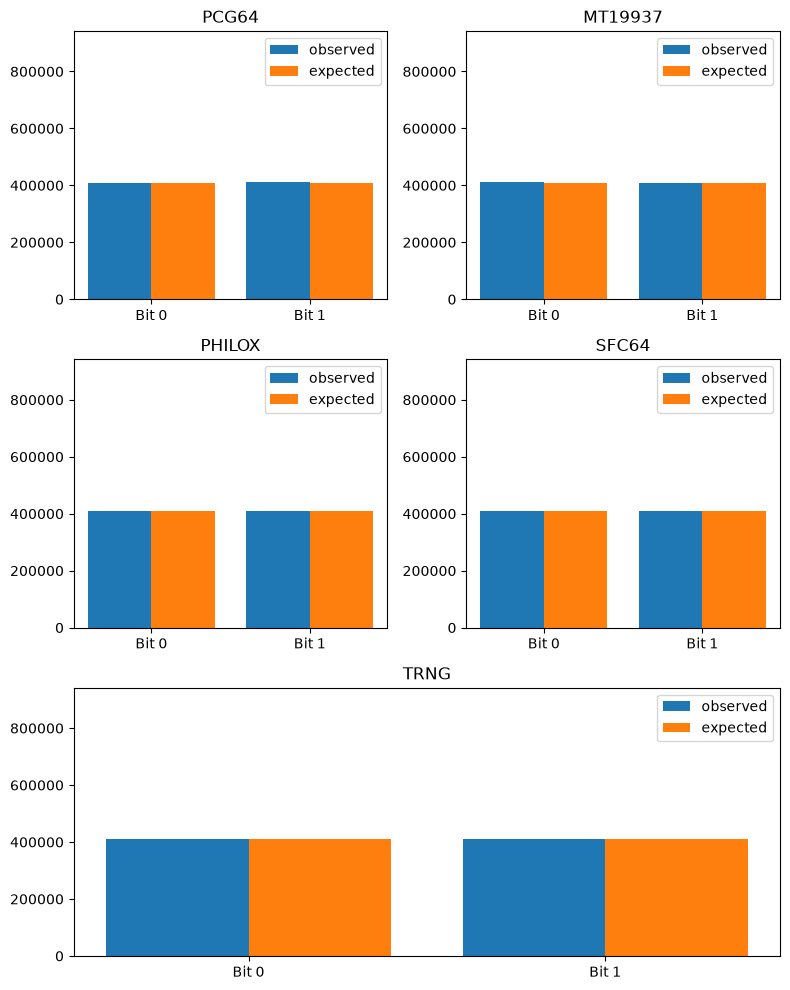

In [27]:
x = np.arange(2)
####
fig = plt.figure(figsize=(8, 10))
gs = fig.add_gridspec(3, 2)
axes = []

for (generator, row, column) in PLOT_MAP:
    if generator == "TRNG":
        ax = fig.add_subplot(gs[row, :])
    else:
        ax = fig.add_subplot(gs[row, column])
    value = next(item[1] for item in data_bin if item[0] == generator)
   
    bit_freq = bit_frequency(value)
    bit_stream_len = len(bytes_to_bits(value))


    observed = [bit_freq["0"], bit_freq["1"]]
    expected = [bit_stream_len / 2, bit_stream_len / 2]
    chi2_stat, p_value = chisquare(observed, expected)
    print(f"{generator}: chi2 = {chi2_stat:.4f}, p-value = {p_value:.4f}")
    
    ax.bar(x - 0.2, observed, 0.4, label = "observed")
    ax.bar(x + 0.2, expected, 0.4, label = "expected")
    ax.set_xticks(x)
    ax.set_xticklabels(["Bit 0", "Bit 1"])
    ax.set_ylim(0, bit_stream_len * 1.15)
    ax.set_title(generator)
    ax.legend() 

    axes.append(ax)


plt.tight_layout()
save_figure("bit_chisquare", BASE_IMAGES_PATH)
plt.show()








Saving figure bit_pvalue_histogram


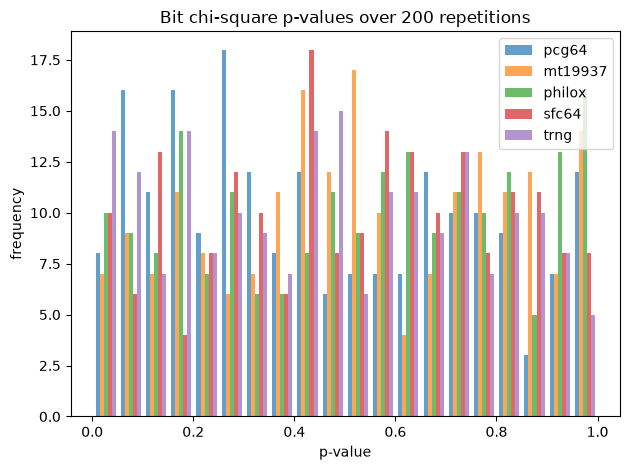

In [28]:
NUM_REPETITIONS = 200

p_values = []
for _ in range(NUM_REPETITIONS):
    data_bin = [
        *[(gen_i.upper(), randint(0, 256, BYTE_STREAM_SIZE, generator=gen_i, dtype=np.uint8).tobytes()) for gen_i in generators],
        ("TRNG",qrandbytes(BYTE_STREAM_SIZE))
        
    ]

    for generator, array in data_bin:
        arr_bit_freq = bit_frequency(array)
        arr_bit_stream_len = len(bytes_to_bits(array))
        
        observed = [arr_bit_freq["0"], arr_bit_freq["1"]]
        expected = [arr_bit_stream_len/2, arr_bit_stream_len/2]
        _, p_value = chisquare(observed, expected)
        p_values.append((generator, p_value))

fig, ax = plt.subplots()
new_generators = generators+ ["trng"]
values = [
     [array for label, array in p_values if label.lower() == generator]
    for generator in new_generators
]

ax.hist(values, bins = 20, label = new_generators, alpha = 0.7)

ax.set_xlabel("p-value")
ax.set_ylabel("frequency")
ax.set_title(f"Bit chi-square p-values over {NUM_REPETITIONS} repetitions")
ax.legend()
save_figure("bit_pvalue_histogram", BASE_IMAGES_PATH)





Saving figure bit_autocorrelation


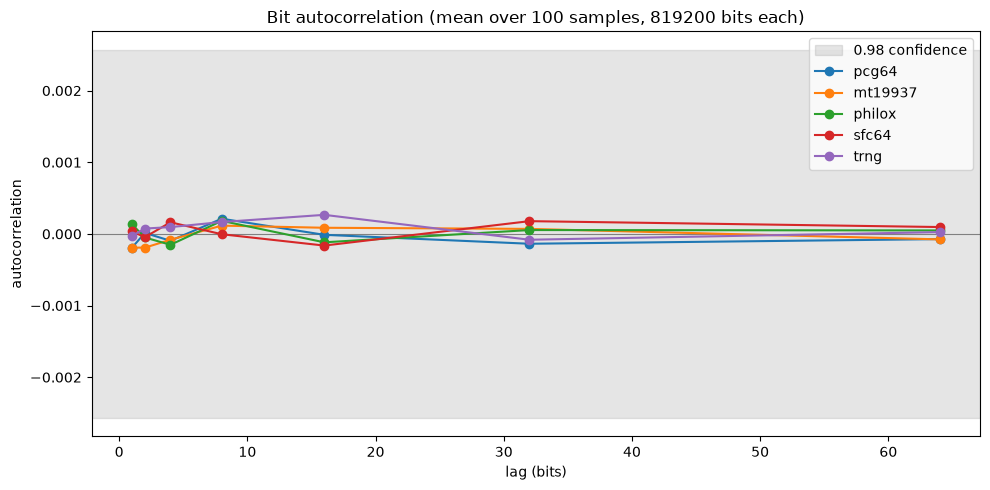

In [29]:
def autocorr(x, lag):
    return np.corrcoef(x[:-lag], x[lag:])[0, 1]

NUM_ACORR_SAMPLES = 100

lags = [1, 2, 4, 8, 16, 32, 64]


acf_samples = []
for _ in range(NUM_ACORR_SAMPLES):
    data_bin = [
        *[(gen_i.upper(), randint(0, 256, BYTE_STREAM_SIZE, generator=gen_i, dtype=np.uint8).tobytes()) for gen_i in generators],
        ("TRNG",qrandbytes(BYTE_STREAM_SIZE))
        
    ]
    for generator, array in data_bin:
        bits = 2.0 * bytes_to_bits(array).astype(np.float64) - 1.0
        acf_samples.append(
            (generator,[autocorr(bits, lag) for lag in lags])
        )  
   
new_generators = generators+ ["trng"]
acf_means = [
    (generator,
     np.mean([acf for label, acf in acf_samples
         if label.lower() == generator.lower()
             ],
             axis = 0
            )
    )
    for generator in new_generators
]
    
n_bits = BYTE_STREAM_SIZE * 8
CONFIDENCE = 0.98

n_bits = BYTE_STREAM_SIZE * 8
z = norm.ppf((1 + CONFIDENCE) / 2)
conf_bound = z / np.sqrt(n_bits)

fig, ax = plt.subplots(figsize=(10, 5))

ax.axhline(0, color="gray", lw=0.8)
ax.axhspan(
    -conf_bound,
    conf_bound,
    alpha=0.2,
    color="gray",
    label=f"{CONFIDENCE} confidence"
)

for generator, acf_mean in acf_means:
    ax.plot(
        lags,
        acf_mean,
        marker="o",
        label=generator
    )

ax.set_xlabel("lag (bits)")
ax.set_ylabel("autocorrelation")
ax.set_title(
    f"Bit autocorrelation "
    f"(mean over {NUM_ACORR_SAMPLES} samples, {n_bits} bits each)"
)
ax.legend()

save_figure("bit_autocorrelation", BASE_IMAGES_PATH)



0.9997146791997493
0.9998335438034707
Saving figure byte_level_tests


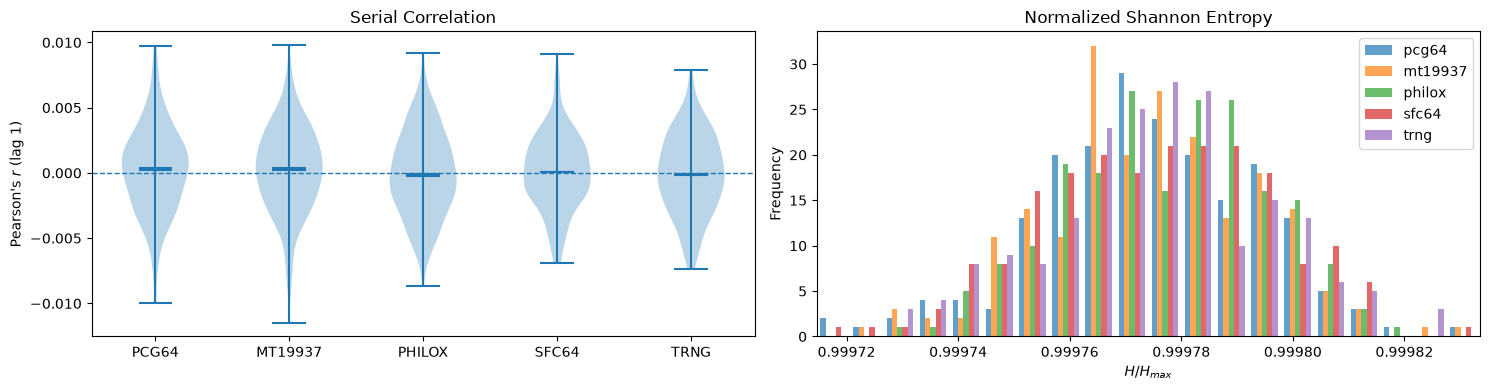

In [30]:
def shannon_entropy(data: bytes) -> float:
    counts = np.bincount(np.frombuffer(data, dtype=np.uint8), minlength=256)
    probs = counts / len(data)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def serial_correlation(data: np.ndarray) -> float:
    x, y = data[:-1].astype(float), data[1:].astype(float)
    if len(x) < 2:
        return 0.0
    return np.corrcoef(x, y)[0, 1]

NUM_BYTE_TESTS = 200

sc_values=[]
entropies=[]

for _ in range(NUM_BYTE_TESTS):
    data_bin = [
        *[(gen_i.upper(), randint(0, 256, BYTE_STREAM_SIZE, generator=gen_i, dtype=np.uint8).tobytes()) for gen_i in generators],
        ("TRNG",qrandbytes(BYTE_STREAM_SIZE))
        
    ]
    for name, stream in data_bin:
        data = np.frombuffer(stream, dtype=np.uint8)

        r = serial_correlation(data)
        sc_values.append((name, r))
        

        h = shannon_entropy(stream)/8
        entropies.append((name, h))


# print("=== Serial Correlation (r between consecutive bytes) ===")
# print(f"{PRNG.upper()} mean r: {np.mean(prng_sc_values):.6f}, std: {np.std(prng_sc_values):.6f}")
# print(f"TRNG mean r: {np.mean(trng_sc_values):.6f}, std: {np.std(trng_sc_values):.6f}")

# print("=== Shannon Entropy (max 8.0 bits) ===")
# print(f"{PRNG.upper()} mean: {np.mean(prng_entropies):.4f}, std: {np.std(prng_entropies):.4f}")
# print(f"TRNG mean: {np.mean(trng_entropies):.4f}, std: {np.std(trng_entropies):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))


new_generators = generators+ ["trng"]

sc_data = [
    [
        r for label, r in sc_values
        if label.lower() == generator.lower()
    ]
    for generator in new_generators
]



axes[0].violinplot(
    sc_data,
    showmeans=True,
    showmedians=True
)

axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_xticks(range(1, len(new_generators) + 1))
axes[0].set_xticklabels([g.upper() for g in new_generators])
axes[0].set_title("Serial Correlation")
axes[0].set_ylabel("Pearson's $r$ (lag 1)")


h_values = [
     [
         array for label, array in entropies 
         if label.lower() == generator
     ]
     for generator in new_generators
]

entropy_values = [h for _, h in entropies]

print(min(entropy_values))
print(max(entropy_values))

axes[1].hist(h_values, bins=20, label=new_generators, alpha=0.7)
axes[1].set_title("Normalized Shannon Entropy")
axes[1].set_xlabel("$H / H_{max}$")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(min(entropy_values), max(entropy_values))
axes[1].legend()

plt.tight_layout()
save_figure("byte_level_tests", BASE_IMAGES_PATH)

# NIST STS

In [31]:
from nist_sp800_22 import run_all_tests

NIST_BYTE_COUNT = 125_000  # 1M bits
NIST_CHUNK = 65536

def qrandbytes_chunked(total_bytes, chunk=NIST_CHUNK) -> bytes:
    chunks = []
    remaining = total_bytes
    while remaining > 0:
        n = min(chunk, remaining)
        chunks.append(qrandbytes(n))
        remaining -= n
    return b"".join(chunks)

nist_results = {}
new_generators = generators+ ["trng"]
for name in new_generators:
    if name == "TRNG".lower():
        stream = qrandbytes_chunked(NIST_BYTE_COUNT)
    else:
        stream = randint(0, 256, NIST_BYTE_COUNT, generator=name, dtype=np.uint8).tobytes()
    nist_results[name] = run_all_tests(stream, label=name)


  pcg64
  125,000 bytes = 1,000,000 bits (0.4s)

  --- NIST SP 800-22 Tests ---
  [PASS] 01 Monobit Frequency: p = 0.144290  (0.3s)
  [PASS] 02 Block Frequency (M=128): p = 0.217069  (0.0s)
  [PASS] 03 Runs Test: p = 0.617167  (0.4s)
  [PASS] 04 Longest Run of Ones: p = 0.101886  (0.1s)
  [PASS] 05 Cumulative Sums (fwd): p = 0.265665  (0.4s)
  [PASS] 06 Cumulative Sums (bwd): p = 0.265665  (0.5s)
  [PASS] 07 Approximate Entropy (m=10): p = 0.726045  (8.5s)
  [PASS] 08 Serial Test (m=16) (1): p = 0.066415  (22.9s)
  [PASS] 08 Serial Test (m=16) (2): p = 0.122990  (22.9s)
  [PASS] 09 Maurer Universal: p = 0.215755  (0.7s)
  [PASS] 10 DFT/Spectral: p = 0.278878  (0.5s)
  [PASS] 11 Binary Matrix Rank: p = 0.325285  (4.7s)
  [PASS] 12 Non-Overlapping Template: p = 0.468939  (1.1s)
  [PASS] 13 Linear Complexity (M=500): p = 0.988195  (72.1s)

  --- Supplementary Tests ---
  [PASS] 14 Chi-Squared Byte: p = 0.110587  (0.0s)
  [INFO] 15 Compression Ratio: 1.000368  (0.0s)
  [PASS] 16 Serial Co

Saving figure nist_results


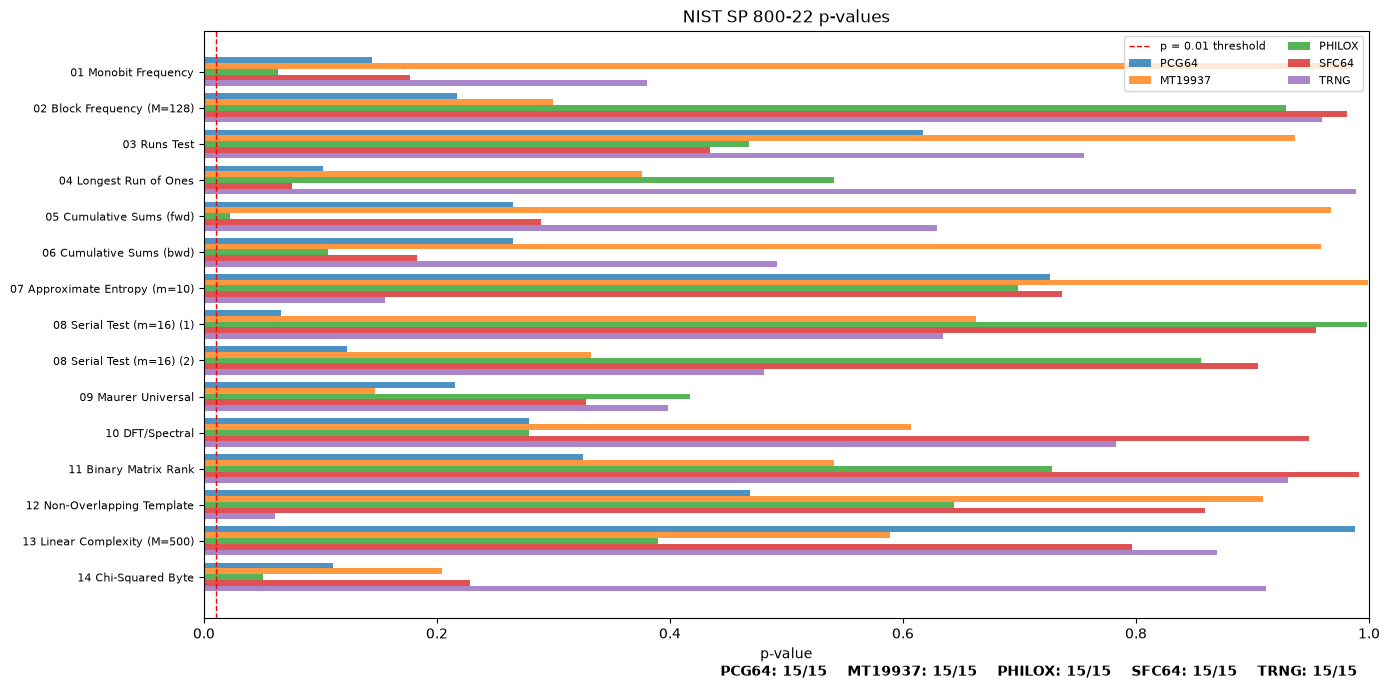

In [32]:
generators = list(nist_results.keys())

# Get test names from the results, keeping only tests that have a p-value.
test_names = [
    test_name
    for test_name, result in next(iter(nist_results.values())).items()
    if "p_value" in result
]

n_generators = len(generators)
n_tests = len(test_names)

fig, ax = plt.subplots(figsize=(14, 7))

y = np.arange(n_tests)

# Total vertical space occupied by all bars belonging to one test.
group_height = 0.8
bar_height = group_height / n_generators

for i, generator in enumerate(generators):

    pvalues = [
        nist_results[generator][test_name]["p_value"]
        for test_name in test_names
    ]

    passed = [
        nist_results[generator][test_name]["passed"]
        for test_name in test_names
    ]

    # Center all generator bars around the test's y position.
    offset = (i - (n_generators - 1) / 2) * bar_height

    ax.barh(
        y + offset,
        pvalues,
        height=bar_height,
        label=generator.upper(),
        alpha=0.8
    )

# Significance threshold
ax.axvline(
    0.01,
    color="red",
    linestyle="--",
    linewidth=1,
    label="p = 0.01 threshold"
)

# Test names
ax.set_yticks(y)
ax.set_yticklabels(test_names, fontsize=8)

ax.set_xlabel("p-value")
ax.set_title("NIST SP 800-22 p-values")

ax.set_xlim(0, 1)
ax.invert_yaxis()

ax.legend(
    fontsize=8,
    ncol=2
)

# Number of passed tests for each generator
summary = "    ".join(
    f"{generator.upper()}: "
    f"{sum(nist_results[generator][test_name]['passed'] for test_name in test_names)}/{n_tests}"
    for generator in generators
)

ax.text(
    0.99,
    -0.08,
    summary,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    fontweight="bold"
)

plt.tight_layout()

save_figure(
    "nist_results",
    BASE_IMAGES_PATH
)

plt.show()